In [1]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from tqdm.notebook import tqdm

project_root = Path.cwd().parent
sys.path.append(str(project_root))

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

print("Librosa version:", librosa.__version__)
print("Project root:", project_root)

Librosa version: 0.11.0
Project root: C:\Users\hsjqo\JupyterProjects\voice analyzer


In [2]:
from datasets import load_from_disk, Audio

dataset = load_from_disk("D:/dusha_final")
print("Структура датасета:", dataset)

# Отключаем автоматическое декодирование аудио – теперь будет доступно поле 'bytes'
dataset = dataset.cast_column("audio", Audio(decode=False))

train_dataset = dataset['train']
train_dataset = train_dataset.shuffle(seed=42).select(range(50000))
print("Уменьшенный размер:", len(train_dataset))
#print("Размер тренировочного сплита:", len(train_dataset))

# Проверим структуру первого примера: теперь audio – словарь с ключами 'bytes' и 'path'
sample = train_dataset[0]
print("Ключи в примере:", sample.keys())
print("Тип audio:", type(sample['audio']))
print("Ключи в audio:", sample['audio'].keys())

Loading dataset from disk:   0%|          | 0/44 [00:00<?, ?it/s]

Структура датасета: DatasetDict({
    train: Dataset({
        features: ['audio', 'emotion'],
        num_rows: 150352
    })
    test: Dataset({
        features: ['audio', 'emotion'],
        num_rows: 14035
    })
})
Уменьшенный размер: 50000
Ключи в примере: dict_keys(['audio', 'emotion'])
Тип audio: <class 'dict'>
Ключи в audio: dict_keys(['bytes', 'path'])


In [3]:
print("Признаки записи:", train_dataset.features)

subset = train_dataset.select(range(min(10000, len(train_dataset))))
emotions = [sample['emotion'] for sample in subset]

from collections import Counter
print("Распределение эмоций (по подвыборке):")
print(Counter(emotions))

Признаки записи: {'audio': Audio(sampling_rate=None, decode=False, num_channels=None, stream_index=None), 'emotion': Value('string')}
Распределение эмоций (по подвыборке):
Counter({'neutral': 6444, 'sad': 1417, 'angry': 1066, 'positive': 978, 'other': 95})


Длительность: 3.06 сек, частота: 16000 Гц


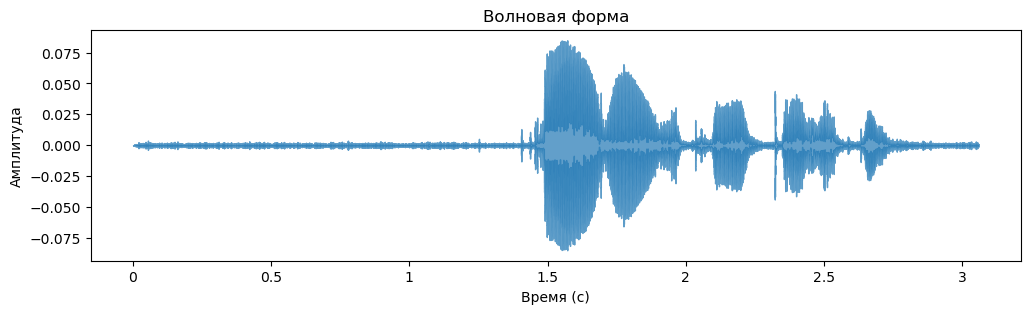

In [4]:
import io

sample = train_dataset[0]
audio_bytes = sample['audio']['bytes']

# Загружаем аудио через librosa прямо из байтов
y, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)

print(f"Длительность: {len(y)/sr:.2f} сек, частота: {sr} Гц")

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, alpha=0.7)
plt.title("Волновая форма")
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.show()

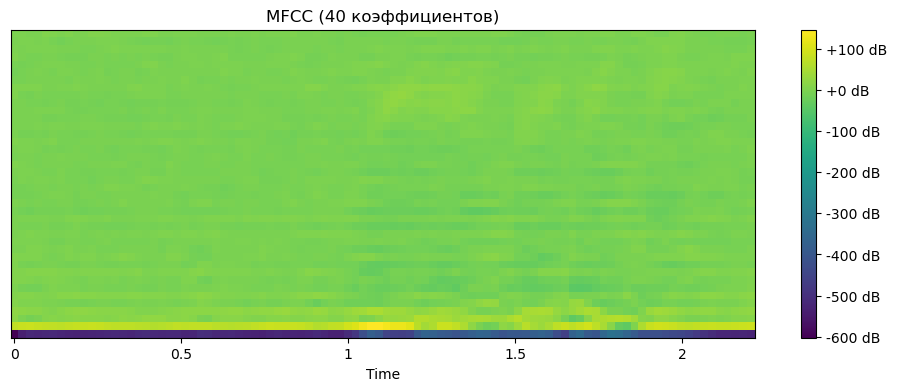

Форма матрицы MFCC: (40, 96)
Усреднённый вектор: (40,)


In [5]:
n_mfcc = 40
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc, x_axis='time', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("MFCC (40 коэффициентов)")
plt.show()

mfcc_mean = np.mean(mfcc, axis=1)
print("Форма матрицы MFCC:", mfcc.shape)
print("Усреднённый вектор:", mfcc_mean.shape)

In [6]:
def extract_features_from_array(y, sr, n_mfcc=40):
    """Извлекает полный вектор признаков из аудио массива."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroid_mean = np.mean(spectral_centroid)

    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    spectral_rolloff_mean = np.mean(spectral_rolloff)

    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = tempo.item() if hasattr(tempo, 'item') else tempo

    features = np.hstack([
        mfcc_mean,
        spectral_centroid_mean,
        spectral_rolloff_mean,
        tempo
    ])
    return features

# Проверка
feat = extract_features_from_array(y, sr)
print("Размер вектора признаков:", feat.shape)

Размер вектора признаков: (43,)


In [7]:
import io

X = []
y_emotion = []

total = len(train_dataset)
for idx, sample in enumerate(train_dataset):
    if idx % 100 == 0:  # выводим каждые 100 примеров
        print(f"Обрабатывается пример {idx}/{total}")
    audio_bytes = sample['audio']['bytes']
    try:
        y_arr, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)
        features = extract_features_from_array(y_arr, sr)
        X.append(features)
        y_emotion.append(sample['emotion'])
    except Exception as e:
        print(f"Ошибка на примере {idx}: {e}")
        continue

print("Обработка завершена")
X = np.array(X)
y_emotion = np.array(y_emotion)

print("Форма X:", X.shape)
if len(X) > 0:
    np.savez(project_root / 'features.npz', X=X, y_emotion=y_emotion)
    print("Признаки сохранены")
else:
    print("ОШИБКА: ни один пример не был обработан!")

Обрабатывается пример 0/50000
Обрабатывается пример 100/50000
Обрабатывается пример 200/50000
Обрабатывается пример 300/50000
Обрабатывается пример 400/50000
Обрабатывается пример 500/50000
Обрабатывается пример 600/50000
Обрабатывается пример 700/50000
Обрабатывается пример 800/50000
Обрабатывается пример 900/50000
Обрабатывается пример 1000/50000
Обрабатывается пример 1100/50000
Обрабатывается пример 1200/50000
Обрабатывается пример 1300/50000
Обрабатывается пример 1400/50000
Обрабатывается пример 1500/50000
Обрабатывается пример 1600/50000
Обрабатывается пример 1700/50000
Обрабатывается пример 1800/50000
Обрабатывается пример 1900/50000
Обрабатывается пример 2000/50000
Обрабатывается пример 2100/50000
Обрабатывается пример 2200/50000
Обрабатывается пример 2300/50000
Обрабатывается пример 2400/50000
Обрабатывается пример 2500/50000
Обрабатывается пример 2600/50000
Обрабатывается пример 2700/50000
Обрабатывается пример 2800/50000
Обрабатывается пример 2900/50000
Обрабатывается пример 